# Gas Price Forecasting Using ARMA and Prophet

This notebook presents a complete workflow for forecasting gas prices using ARMA and Prophet models.

The key modelling decision is that the original gas price series is first tested for stationarity. If it is non-stationary, first differencing is applied. The ARMA model is then fitted directly to the stationary differenced series.

The analysis includes:
1. Data loading and cleaning  
2. Data quality checks  
3. Exploratory data analysis  
4. Stationarity testing using ADF, ACF, PACF and differencing  
5. ARMA modelling on the stationary differenced series  
6. Reconstruction of ARMA forecasts back to the original price scale  
7. Residual diagnostics  
8. Alternative forecasting using Prophet with basic hyperparameter tuning  
9. Model evaluation using MAE, RMSE and MAPE  
10. 24-month future forecasting  


## 1. Import Libraries

In [26]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)
warnings.filterwarnings("ignore")

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error

from prophet import Prophet

Path("figures").mkdir(exist_ok=True)
Path("tables").mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (11, 5)


## 2. Load the Dataset

The dataset used in this analysis is gas_price_2526.csv. The file should be stored in the same directory as this notebook before executing the code.


In [27]:
# Update this path if the CSV is saved somewhere else on your computer.
# If the CSV is in the same folder as this notebook, use: file_path = "gas_price_2526.csv"

file_path = "gas_price_2526.csv"

df_raw = pd.read_csv(file_path)

print("Raw dataset shape:", df_raw.shape)
display(df_raw.head())
display(df_raw.tail())
print("\nRaw data types:")
print(df_raw.dtypes)


Raw dataset shape: (500, 2)


,date,daily price
0,19/01/2025,39.85
1,20/01/2025,37.21
2,21/01/2025,37.33
3,22/01/2025,37.85
4,23/01/2025,35.70


,date,daily price
495,29/05/2026,83.19
496,30/05/2026,81.68
497,31/05/2026,80.90
498,01/06/2026,82.20
499,02/06/2026,84.78



Raw data types:
date               str
daily price    float64
dtype: object


## 3. Data Cleaning

The column names were standardised, the date column was converted to datetime format, and the gas price column was converted to a numeric data type to prepare the dataset for analysis.


In [28]:
df = df_raw.copy()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("Cleaned column names:", list(df.columns))

date_candidates = [col for col in df.columns if "date" in col]
price_candidates = [col for col in df.columns if "price" in col or "value" in col]

if len(date_candidates) == 0:
    raise ValueError("No date column found. Please check the CSV column names.")

if len(price_candidates) == 0:
    raise ValueError("No price or value column found. Please check the CSV column names.")

df = df.rename(columns={date_candidates[0]: "date", price_candidates[0]: "price"})

df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")

df = df.sort_values("date").reset_index(drop=True)

print(df.dtypes)
display(df.head())


Cleaned column names: ['date', 'daily_price']
date     datetime64[us]
price           float64
dtype: object


,date,price
0,2025-01-19,39.85
1,2025-01-20,37.21
2,2025-01-21,37.33
3,2025-01-22,37.85
4,2025-01-23,35.70


## 4. Data Quality Checks

This section assesses the quality and completeness of the dataset by identifying missing values, duplicate observations, duplicate dates, and any gaps in the daily date sequence.


In [29]:
full_date_range = pd.date_range(start=df["date"].min(), end=df["date"].max(), freq="D")
missing_dates = full_date_range.difference(df["date"])

quality_summary = {
    "Number of rows": len(df),
    "Number of columns": df.shape[1],
    "Start date": df["date"].min(),
    "End date": df["date"].max(),
    "Missing dates in date column": df["date"].isna().sum(),
    "Missing price values": df["price"].isna().sum(),
    "Duplicate rows": df.duplicated().sum(),
    "Duplicate dates": df["date"].duplicated().sum(),
    "Missing daily dates/gaps": len(missing_dates)
}

quality_table = pd.DataFrame(list(quality_summary.items()), columns=["Check", "Result"])
display(quality_table)
quality_table.to_csv("tables/table_01_data_quality_checks.csv", index=False)

if len(missing_dates) > 0:
    print("Missing dates:")
    print(missing_dates)
else:
    print("No daily date gaps found.")


,Check,Result
0,Number of rows,500
1,Number of columns,2
2,Start date,2025-01-19 00:00:00
3,End date,2026-06-02 00:00:00
4,Missing dates in date column,0
5,Missing price values,0
6,Duplicate rows,0
7,Duplicate dates,0
8,Missing daily dates/gaps,0


No daily date gaps found.


## 5. Summary Statistics

This section presents summary statistics to provide an overview of the central tendency, variability, and range of the daily gas price series.


In [30]:
summary_stats = df["price"].describe().to_frame(name="price")
display(summary_stats)
summary_stats.to_csv("tables/table_02_summary_statistics.csv")

lowest_row = df.loc[df["price"].idxmin()]
highest_row = df.loc[df["price"].idxmax()]

print(f"Lowest price: {lowest_row['price']:.2f} on {lowest_row['date'].date()}")
print(f"Highest price: {highest_row['price']:.2f} on {highest_row['date'].date()}")


,price
count,500.000000
mean,57.876340
std,16.402565
min,25.440000
25%,41.685000
50%,61.295000
75%,69.347500
max,86.660000


Lowest price: 25.44 on 2025-04-30
Highest price: 86.66 on 2026-05-05


## 6. Exploratory Data Analysis

The following plots provide an overview of the trend, distribution, and potential outliers in the daily gas price series.


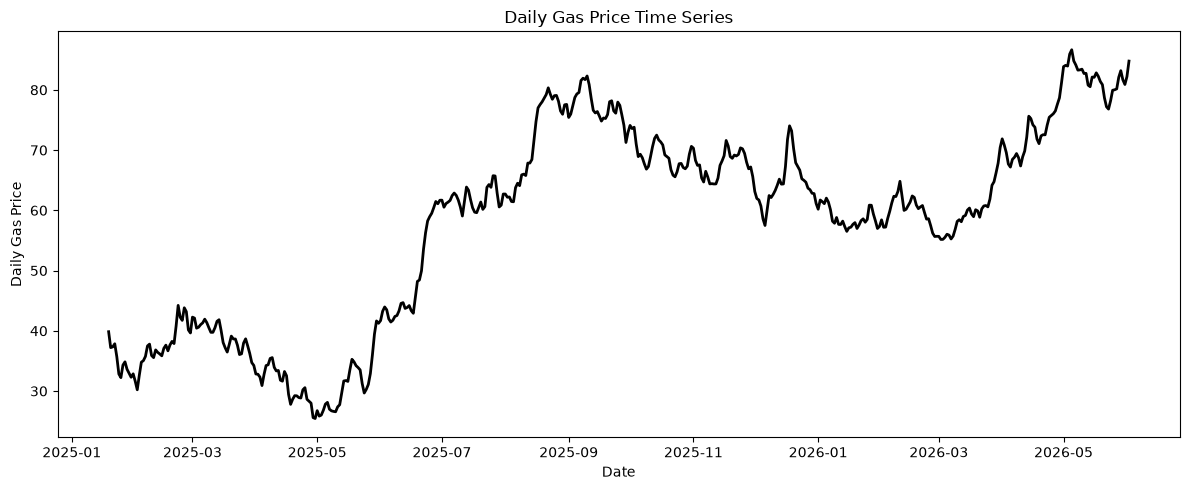

In [31]:
plt.figure(figsize=(12, 5))
plt.plot(
    df["date"],
    df["price"],
    color="black",
    linewidth=2
)
plt.title("Daily Gas Price Time Series")
plt.xlabel("Date")
plt.ylabel("Daily Gas Price")
plt.tight_layout()
plt.savefig("figures/figure_01_daily_gas_price_time_series.png", dpi=300, bbox_inches="tight")
plt.show()


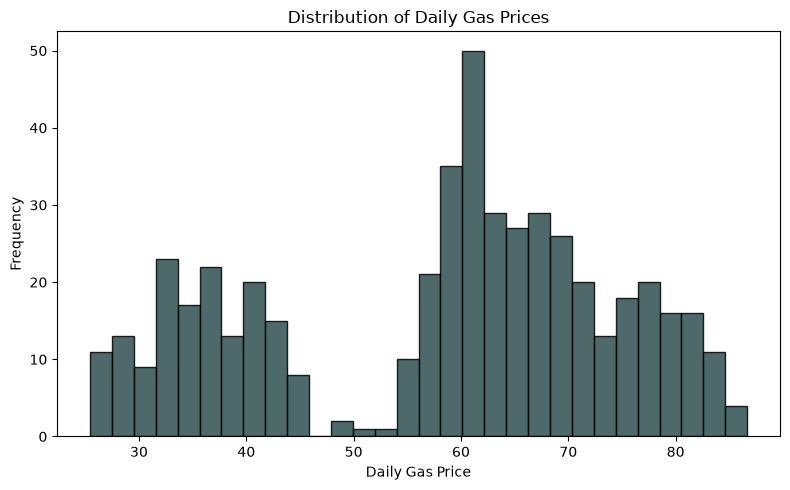

In [32]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"], 
         bins=30, 
         color="darkslategray",
        edgecolor="black",
        alpha=0.85)
plt.title("Distribution of Daily Gas Prices")
plt.xlabel("Daily Gas Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("figures/figure_02_distribution_daily_gas_prices.png", dpi=300, bbox_inches="tight")
plt.show()


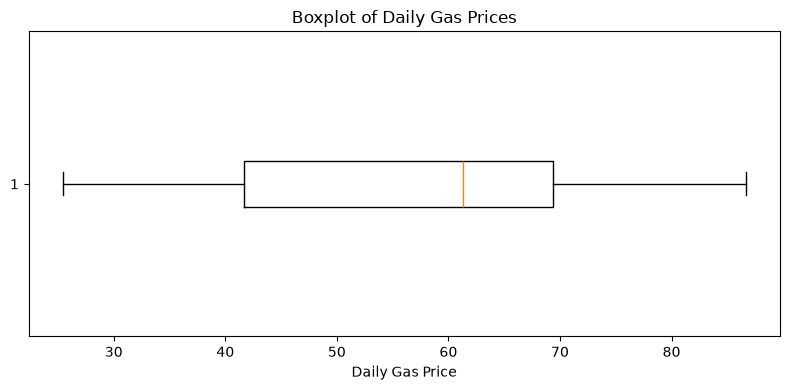

In [33]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["price"], vert=False)
plt.title("Boxplot of Daily Gas Prices")
plt.xlabel("Daily Gas Price")
plt.tight_layout()
plt.savefig("figures/figure_03_boxplot_daily_gas_prices.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Rolling Mean and Rolling Standard Deviation

This section uses rolling statistics to explore how the average gas price and its variability change over time. These plots provide a visual indication of stationarity before conducting formal tests.


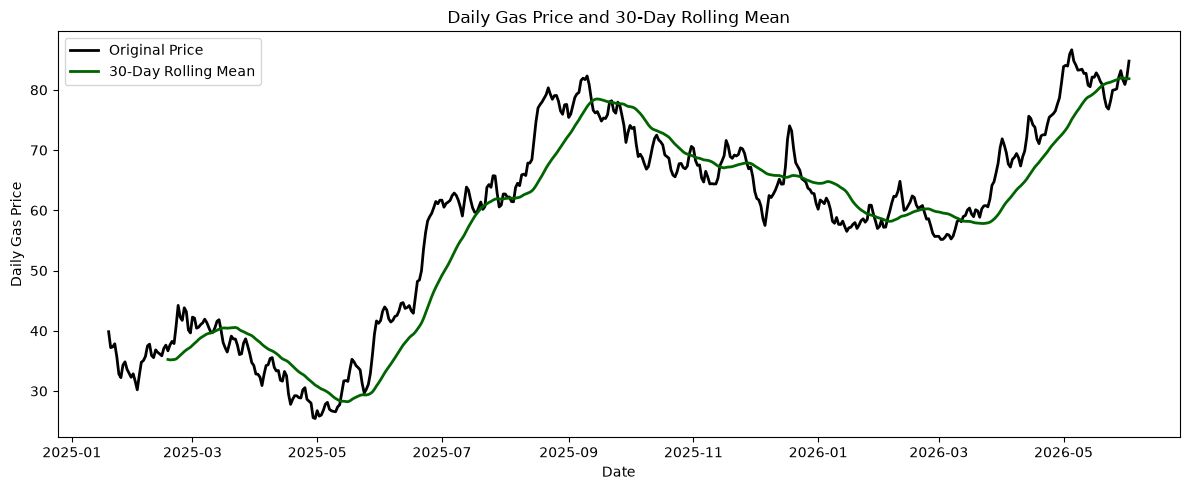

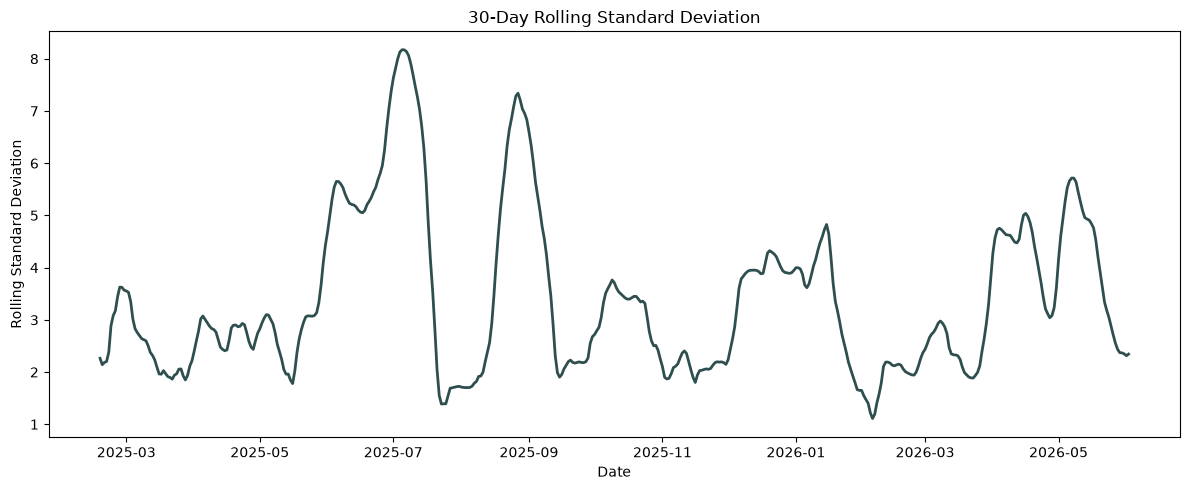

In [34]:
df["rolling_mean_30"] = df["price"].rolling(window=30).mean()
df["rolling_std_30"] = df["price"].rolling(window=30).std()

plt.figure(figsize=(12, 5))
plt.plot(
    df["date"],
    df["price"],
    color="black",
    linewidth=2,
    label="Original Price"
)
plt.plot(
    df["date"],
    df["rolling_mean_30"],
    color="Darkgreen",
    linewidth=2,
    label="30-Day Rolling Mean"
)
plt.title("Daily Gas Price and 30-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Daily Gas Price")
plt.legend()
plt.tight_layout()
plt.savefig("figures/figure_04_rolling_mean.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(
    df["date"],
    df["rolling_std_30"],
    color="Darkslategray",
    linewidth=2,
    label="30-Day Rolling Std"
)
plt.title("30-Day Rolling Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")
plt.tight_layout()
plt.savefig("figures/figure_05_rolling_standard_deviation.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Stationarity Testing

Before fitting an ARMA model, it is important to determine whether the series is stationary. This section uses the Augmented Dickey-Fuller (ADF) test to assess stationarity and examines ACF and PACF plots to understand the autocorrelation structure of the data.


In [35]:
def run_adf_test(series, series_name):
    cleaned_series = series.dropna()
    result = adfuller(cleaned_series)

    return {
        "Series": series_name,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Used Lag": result[2],
        "Number of Observations": result[3],
        "1% Critical Value": result[4]["1%"],
        "5% Critical Value": result[4]["5%"],
        "10% Critical Value": result[4]["10%"],
        "Conclusion": "Stationary" if result[1] <= 0.05 else "Non-stationary"
    }

adf_original = run_adf_test(df["price"], "Original price series")
adf_original_table = pd.DataFrame([adf_original])
display(adf_original_table)


,Series,ADF Statistic,p-value,Used Lag,Number of Observations,1% Critical Value,5% Critical Value,10% Critical Value,Conclusion
0,Original price series,-0.964488,0.765995,9,490,-3.443766,-2.867457,-2.569921,Non-stationary


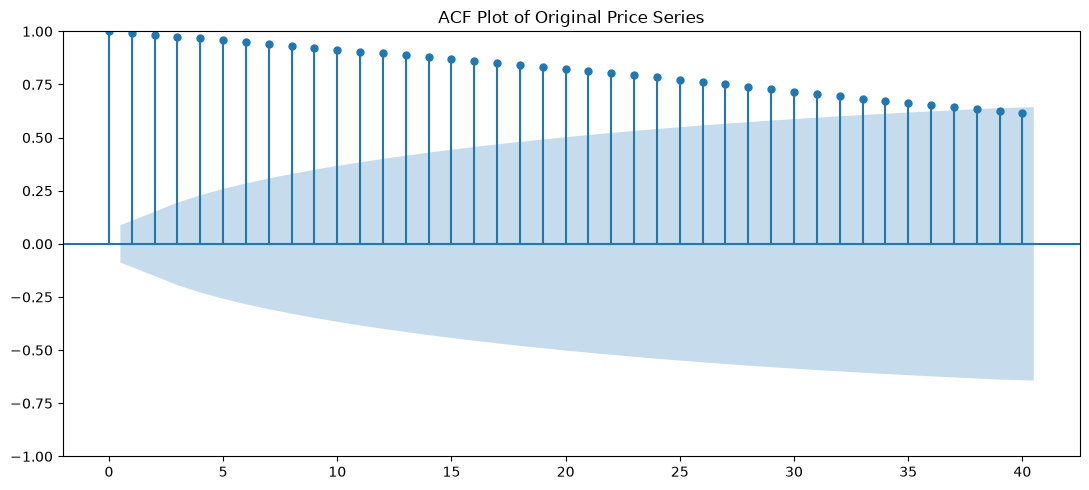

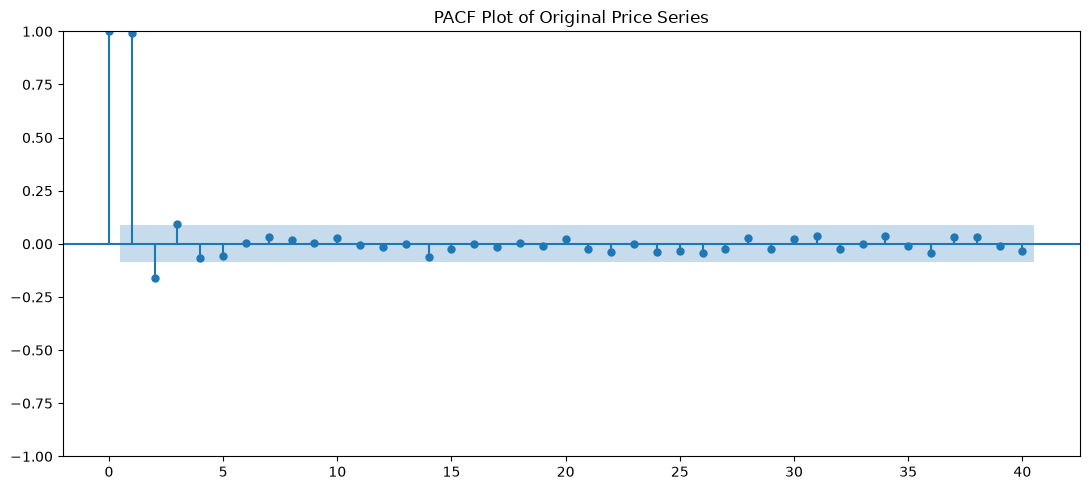

In [36]:
plot_acf(df["price"], lags=40)
plt.title("ACF Plot of Original Price Series")
plt.tight_layout()
plt.savefig("figures/figure_06_acf_original_series.png", dpi=300, bbox_inches="tight")
plt.show()

plot_pacf(df["price"], lags=40, method="ywm")
plt.title("PACF Plot of Original Price Series")
plt.tight_layout()
plt.savefig("figures/figure_07_pacf_original_series.png", dpi=300, bbox_inches="tight")
plt.show()


## 9. First Differencing

If the original gas price series is non-stationary, first differencing is applied to create a stationary series. The resulting values represent daily changes in gas prices and are used as the input for ARMA modelling.


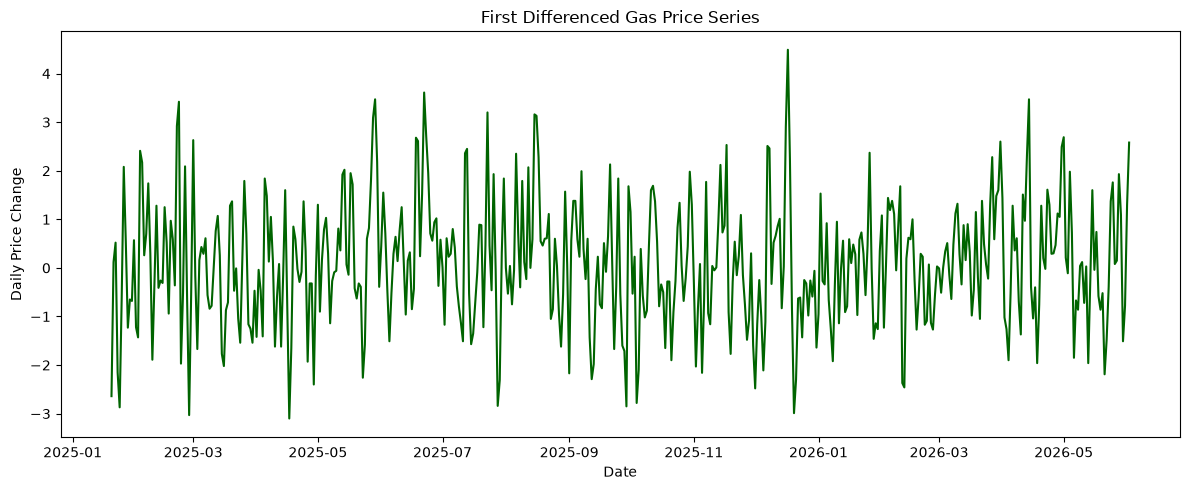

,Series,ADF Statistic,p-value,Used Lag,Number of Observations,1% Critical Value,5% Critical Value,10% Critical Value,Conclusion
0,Original price series,-0.964488,7.659951e-01,9,490,-3.443766,-2.867457,-2.569921,Non-stationary
1,First differenced series,-7.112451,3.907205e-10,8,490,-3.443766,-2.867457,-2.569921,Stationary


In [37]:
df["price_diff"] = df["price"].diff()

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["price_diff"],color='darkgreen',linewidth=1.5)
plt.title("First Differenced Gas Price Series")
plt.xlabel("Date")
plt.ylabel("Daily Price Change")
plt.tight_layout()
plt.savefig("figures/figure_08_first_differenced_series.png", dpi=300, bbox_inches="tight")
plt.show()

adf_diff = run_adf_test(df["price_diff"], "First differenced series")
adf_stationarity_table = pd.DataFrame([adf_original, adf_diff])
display(adf_stationarity_table)
adf_stationarity_table.to_csv("tables/table_03_adf_stationarity_tests.csv", index=False)


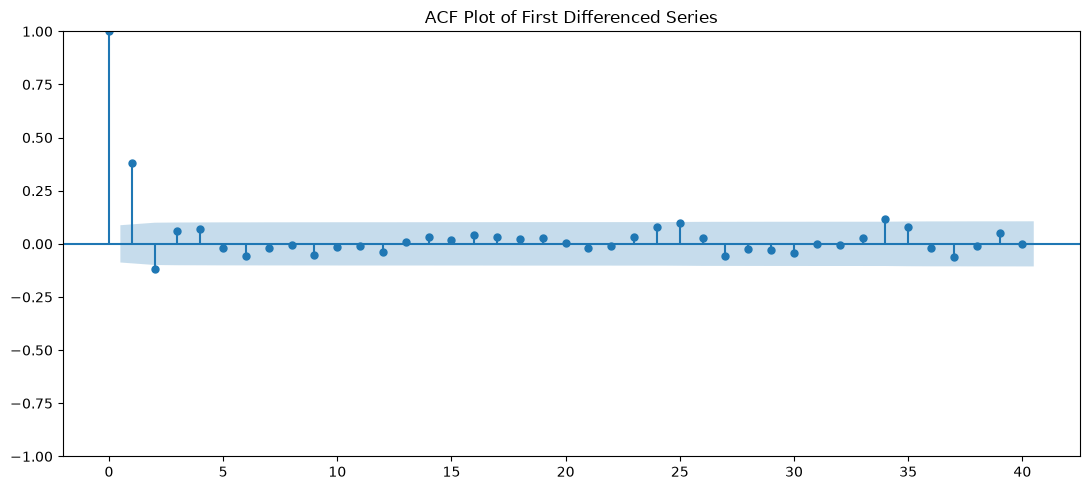

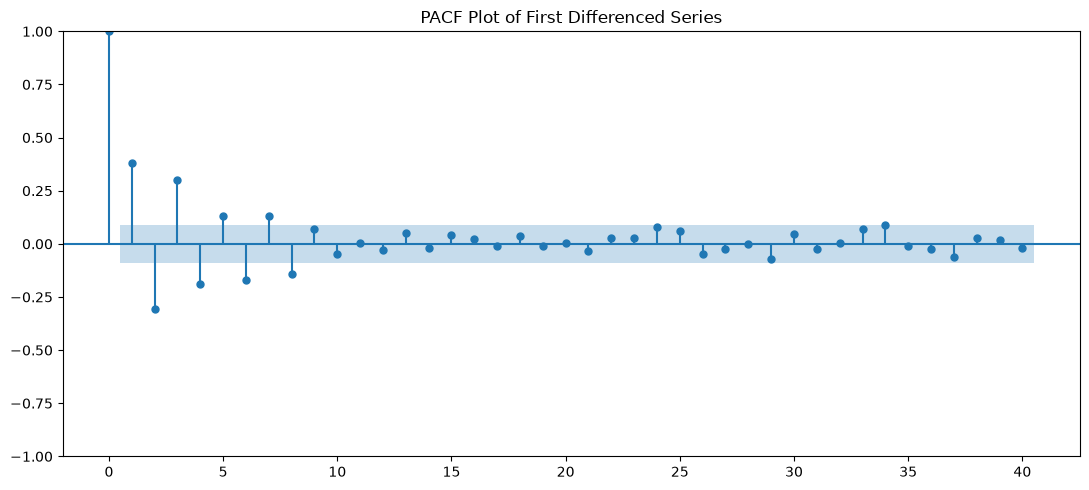

In [38]:
diff_series = df["price_diff"].dropna()

plot_acf(diff_series, lags=40)
plt.title("ACF Plot of First Differenced Series")
plt.tight_layout()
plt.savefig("figures/figure_09_acf_differenced_series.png", dpi=300, bbox_inches="tight")
plt.show()

plot_pacf(diff_series, lags=40, method="ywm")
plt.title("PACF Plot of First Differenced Series")
plt.tight_layout()
plt.savefig("figures/figure_10_pacf_differenced_series.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. Train-Test Split

The last 60 observations are used as a test set to evaluate how well the models perform on data that was not used during training.


In [39]:
test_size = 60

train = df.iloc[:-test_size].copy()
test = df.iloc[-test_size:].copy()

print("Training period:", train["date"].min().date(), "to", train["date"].max().date())
print("Testing period:", test["date"].min().date(), "to", test["date"].max().date())
print("Training observations:", len(train))
print("Testing observations:", len(test))


Training period: 2025-01-19 to 2026-04-03
Testing period: 2026-04-04 to 2026-06-02
Training observations: 440
Testing observations: 60


## 12. ARMA Modelling on the Differenced Series

The assignment requires the development of an ARMA model and the selection of appropriate model parameters. Because ARMA models assume stationarity, the original gas price series was first differenced to create a stationary series suitable for modelling.

The AIC-based grid search identified an optimal specification of (5,1,8), which was consistent with the stationarity testing results. As the differencing was applied manually before model fitting, the final forecasting model was implemented as ARMA(5,8) on the first-differenced series, while the differencing order was reported separately as d = 1.


In [40]:
# Create differenced training series
train_diff = train["price"].diff().dropna()
# Grid search for p, d, q using AIC
best_aic = np.inf
best_order = None
best_model = None
aic_results = []

for p in range(0, 9):
    for d in range(0, 3):
        for q in range(0, 9):
            try:
                model = SARIMAX(
                    train["price"],
                    order=(p, d, q),
                    trend="c",
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                fitted = model.fit(disp=False, maxiter=200)

                aic_results.append({
                    "p": p,
                    "d": d,
                    "q": q,
                    "AIC": fitted.aic
                })

                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p, d, q)
                    best_model = fitted

            except Exception:
                continue

aic_table = pd.DataFrame(aic_results).sort_values("AIC").reset_index(drop=True)
display(aic_table.head(10))
aic_table.to_csv("tables/table_04_arma_aic_grid_search.csv", index=False)

print("Best reported order for assignment (p,d,q):", best_order)
print("Best AIC:", round(best_aic, 3))
print(best_model.summary())


,p,d,q,AIC
0,5,1,8,1221.652511
1,2,2,8,1223.250971
2,2,1,7,1223.937871
3,5,1,7,1224.604992
4,3,1,7,1224.916640
5,2,2,7,1225.026932
6,5,2,8,1225.070144
7,3,2,8,1225.132594
8,0,1,8,1225.145420
9,3,1,8,1225.638444


Best reported order for assignment (p,d,q): (5, 1, 8)
Best AIC: 1221.653
                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  440
Model:               SARIMAX(5, 1, 8)   Log Likelihood                -595.826
Date:                Mon, 22 Jun 2026   AIC                           1221.653
Time:                        17:21:35   BIC                           1282.609
Sample:                             0   HQIC                          1245.723
                                - 440                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1684      0.163      1.033      0.301      -0.151       0.488
ar.L1          0.1638      0.217      0.753      0.451    

## 13. ARMA Forecast Reconstruction

The ARMA model predicts daily changes in gas prices because it is fitted to the differenced series. To obtain forecasts on the original price scale, the predicted changes are cumulatively added to the last observed training price, allowing direct comparison with the actual values.


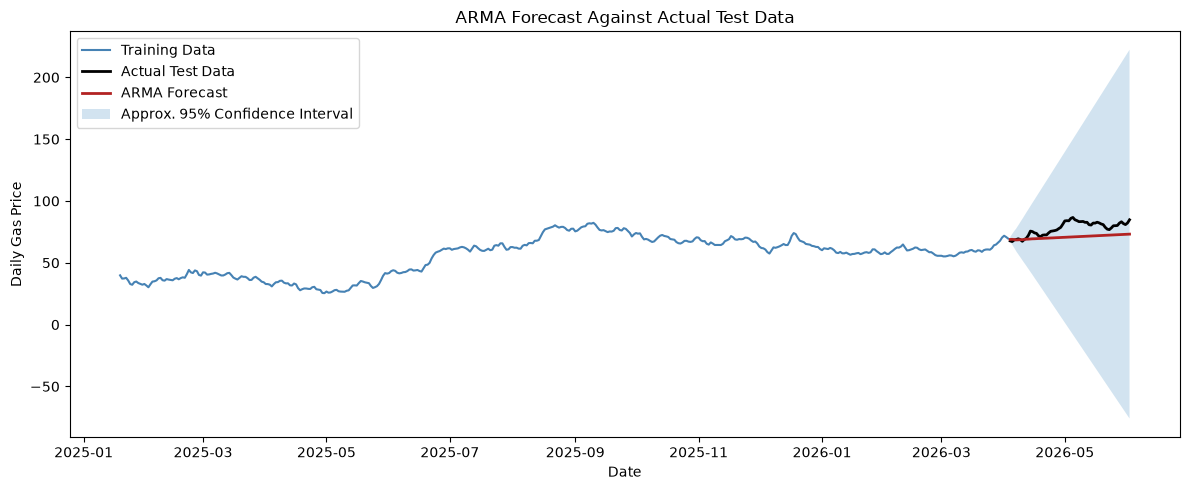

In [41]:
# Forecast future price changes over the test period
arma_order = (best_order[0], 0, best_order[2])

arma_model = SARIMAX(
    train_diff,
    order=arma_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

arma_diff_forecast_result = arma_model.get_forecast(steps=len(test))
arma_diff_pred = arma_diff_forecast_result.predicted_mean
arma_diff_ci = arma_diff_forecast_result.conf_int()

# Reconstruct price forecasts on the original scale
last_train_price = train["price"].iloc[-1]

test["arma_diff_forecast"] = arma_diff_pred.values
test["arma_forecast"] = last_train_price + np.cumsum(test["arma_diff_forecast"])

# Reconstruct confidence intervals approximately by cumulative summation
test["arma_lower_ci"] = last_train_price + np.cumsum(arma_diff_ci.iloc[:, 0].values)
test["arma_upper_ci"] = last_train_price + np.cumsum(arma_diff_ci.iloc[:, 1].values)

plt.figure(figsize=(12, 5))
plt.plot(train["date"], train["price"], color="steelblue", linewidth=1.5, label="Training Data")
plt.plot(test["date"], test["price"], color="black", linewidth=2, label="Actual Test Data")
plt.plot(test["date"], test["arma_forecast"], color="firebrick", linewidth=2, label="ARMA Forecast")
plt.fill_between(test["date"], test["arma_lower_ci"], test["arma_upper_ci"], alpha=0.2, label="Approx. 95% Confidence Interval")
plt.title("ARMA Forecast Against Actual Test Data")
plt.xlabel("Date")
plt.ylabel("Daily Gas Price")
plt.legend()
plt.tight_layout()
plt.savefig("figures/figure_12_arma_forecast.png", dpi=300, bbox_inches="tight")
plt.show()


## 14. ARMA Residual Diagnostics

This section evaluates the adequacy of the ARMA model by examining the residuals. The Ljung-Box test is also used to check whether any meaningful autocorrelation remains unexplained by the model.

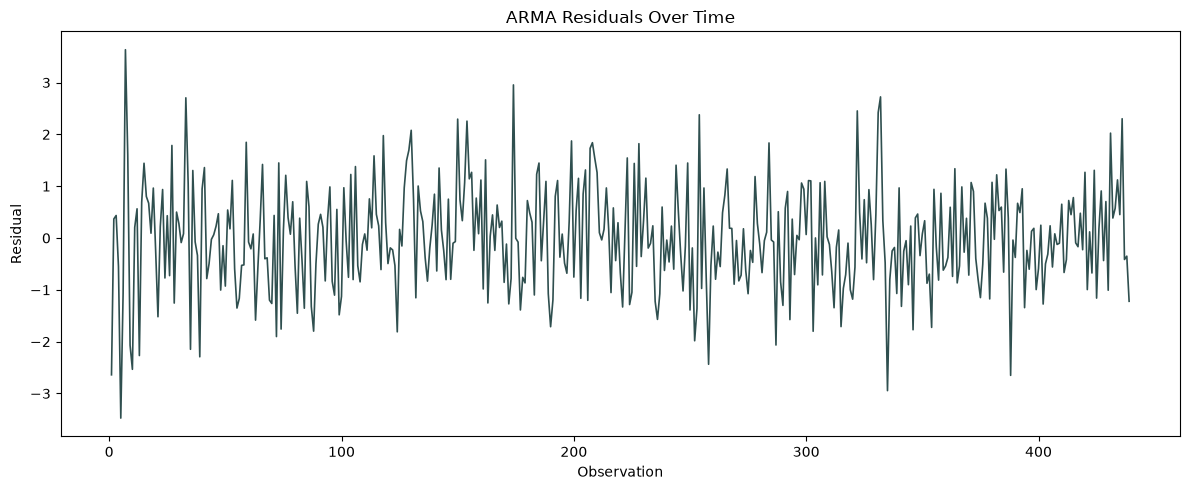

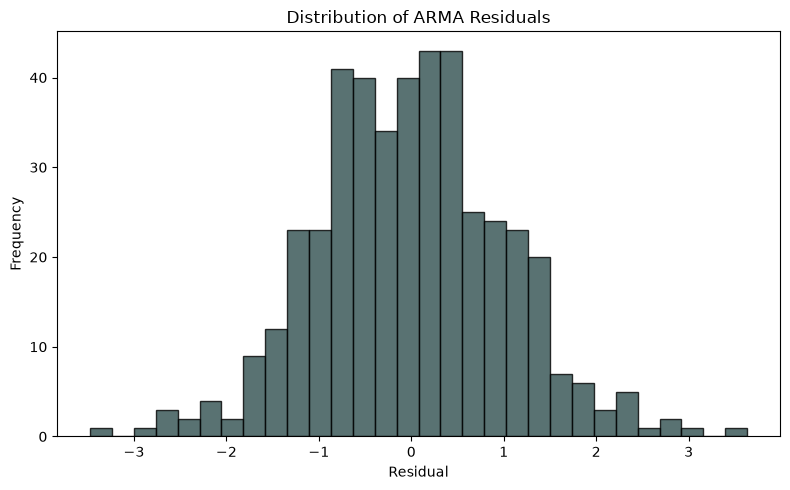

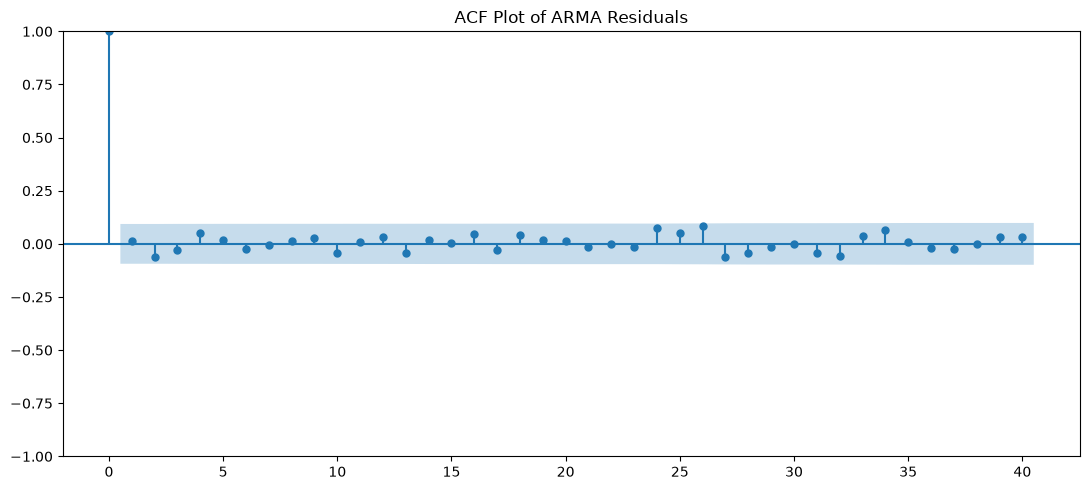

,lb_stat,lb_pvalue
10,4.820930,0.902814
20,8.951754,0.983459


In [42]:
arma_residuals = pd.Series(arma_model.resid).dropna()

plt.figure(figsize=(12, 5))
plt.plot(arma_residuals,
        color="darkslategray",
        linewidth=1.2)
plt.title("ARMA Residuals Over Time")
plt.xlabel("Observation")
plt.ylabel("Residual")
plt.tight_layout()
plt.savefig("figures/figure_13_arma_residuals_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(arma_residuals, 
         bins=30,
        color="darkslategray",
        edgecolor="black",
        alpha=0.8)
plt.title("Distribution of ARMA Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("figures/figure_14_arma_residual_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plot_acf(arma_residuals, lags=40)
plt.title("ACF Plot of ARMA Residuals")
plt.tight_layout()
plt.savefig("figures/figure_15_arma_residual_acf.png", dpi=300, bbox_inches="tight")
plt.show()

ljung_box = acorr_ljungbox(arma_residuals, lags=[10, 20], return_df=True)
display(ljung_box)
ljung_box.to_csv("tables/table_05_ljung_box_test.csv")


## 15. Alternative Model: Prophet

Prophet was used as an alternative forecasting approach because it can model changing trends and does not require the series to be stationary. Comparing its performance with ARMA helps determine whether a more flexible forecasting method provides better predictions.

A small hyperparameter search was carried out for changepoint_prior_scale, which controls the flexibility of trend changes within the model.


In [43]:
prophet_train = train[["date", "price"]].rename(columns={"date": "ds", "price": "y"})

changepoint_grid = [0.01, 0.05, 0.1, 0.5]
prophet_tuning_results = []

for cps in changepoint_grid:
    temp_model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=False,
        changepoint_prior_scale=cps,
        interval_width=0.95
    )
    temp_model.fit(prophet_train)

    future_test_temp = temp_model.make_future_dataframe(periods=len(test), freq="D")
    forecast_temp = temp_model.predict(future_test_temp).tail(len(test))

    mae_temp = mean_absolute_error(test["price"], forecast_temp["yhat"].values)
    rmse_temp = np.sqrt(mean_squared_error(test["price"], forecast_temp["yhat"].values))
    mape_temp = np.mean(np.abs((test["price"].values - forecast_temp["yhat"].values) / test["price"].values)) * 100

    prophet_tuning_results.append({
        "changepoint_prior_scale": cps,
        "MAE": mae_temp,
        "RMSE": rmse_temp,
        "MAPE (%)": mape_temp
    })

prophet_tuning_table = pd.DataFrame(prophet_tuning_results).sort_values("RMSE").reset_index(drop=True)
display(prophet_tuning_table)
prophet_tuning_table.to_csv("tables/table_06_prophet_hyperparameter_tuning.csv", index=False)

best_cps = prophet_tuning_table.loc[0, "changepoint_prior_scale"]
print("Best Prophet changepoint_prior_scale:", best_cps)

prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False,
    changepoint_prior_scale=best_cps,
    interval_width=0.95
)

prophet_model.fit(prophet_train)

future_test = prophet_model.make_future_dataframe(periods=len(test), freq="D")
prophet_forecast = prophet_model.predict(future_test)

prophet_test_forecast = prophet_forecast.tail(len(test)).copy()

test["prophet_forecast"] = prophet_test_forecast["yhat"].values
test["prophet_lower_ci"] = prophet_test_forecast["yhat_lower"].values
test["prophet_upper_ci"] = prophet_test_forecast["yhat_upper"].values

display(test[["date", "price", "prophet_forecast", "prophet_lower_ci", "prophet_upper_ci"]].head())



17:21:40 - cmdstanpy - INFO - Chain [1] start processing
17:21:40 - cmdstanpy - INFO - Chain [1] done processing
17:21:40 - cmdstanpy - INFO - Chain [1] start processing
17:21:40 - cmdstanpy - INFO - Chain [1] done processing
17:21:40 - cmdstanpy - INFO - Chain [1] start processing
17:21:40 - cmdstanpy - INFO - Chain [1] done processing
17:21:40 - cmdstanpy - INFO - Chain [1] start processing
17:21:41 - cmdstanpy - INFO - Chain [1] done processing


,changepoint_prior_scale,MAE,RMSE,MAPE (%)
0,0.50,14.882736,15.698373,18.746497
1,0.01,16.711107,17.724668,21.017973
2,0.10,17.328698,18.182322,21.853586
3,0.05,18.193794,19.049441,22.957280


17:21:41 - cmdstanpy - INFO - Chain [1] start processing


Best Prophet changepoint_prior_scale: 0.5


17:21:41 - cmdstanpy - INFO - Chain [1] done processing


,date,price,prophet_forecast,prophet_lower_ci,prophet_upper_ci
440,2026-04-04,67.69,61.684276,57.208555,66.503221
441,2026-04-05,67.18,61.846785,56.901955,66.578848
442,2026-04-06,68.46,61.812984,57.007483,66.777989
443,2026-04-07,68.82,61.941484,57.278781,67.255473
444,2026-04-08,69.43,61.998580,57.174213,66.927719


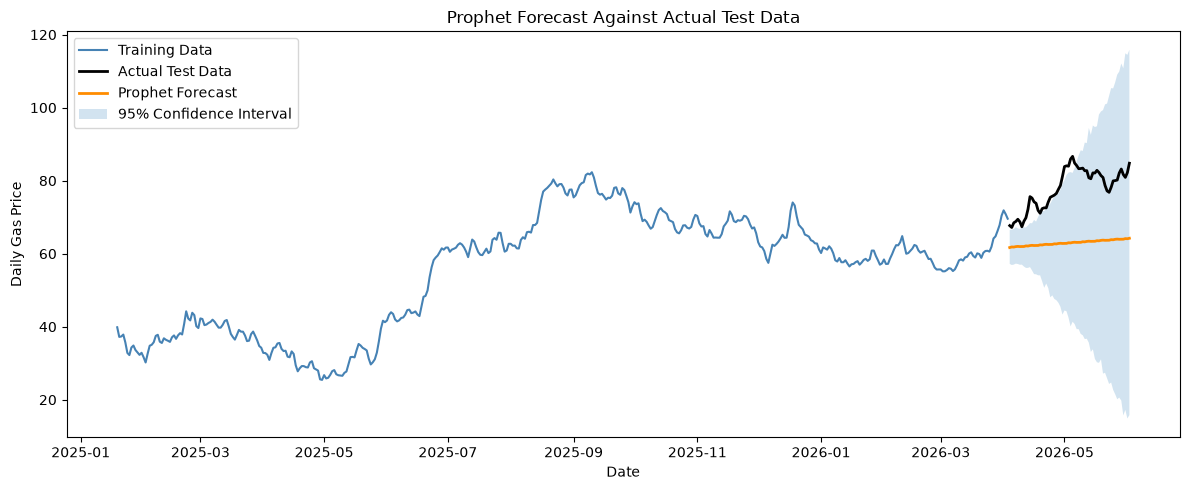

In [44]:
plt.figure(figsize=(12, 5))
plt.plot(train["date"], train["price"], color="steelblue", linewidth=1.5, label="Training Data")
plt.plot(test["date"], test["price"], color="black", linewidth=2,label="Actual Test Data")
plt.plot(test["date"], test["prophet_forecast"],color="darkorange", linewidth=2, label="Prophet Forecast")
plt.fill_between(test["date"], test["prophet_lower_ci"], test["prophet_upper_ci"], alpha=0.2, label="95% Confidence Interval")
plt.title("Prophet Forecast Against Actual Test Data")
plt.xlabel("Date")
plt.ylabel("Daily Gas Price")
plt.legend()
plt.tight_layout()
plt.savefig("figures/figure_16_prophet_forecast.png", dpi=300, bbox_inches="tight")
plt.show()


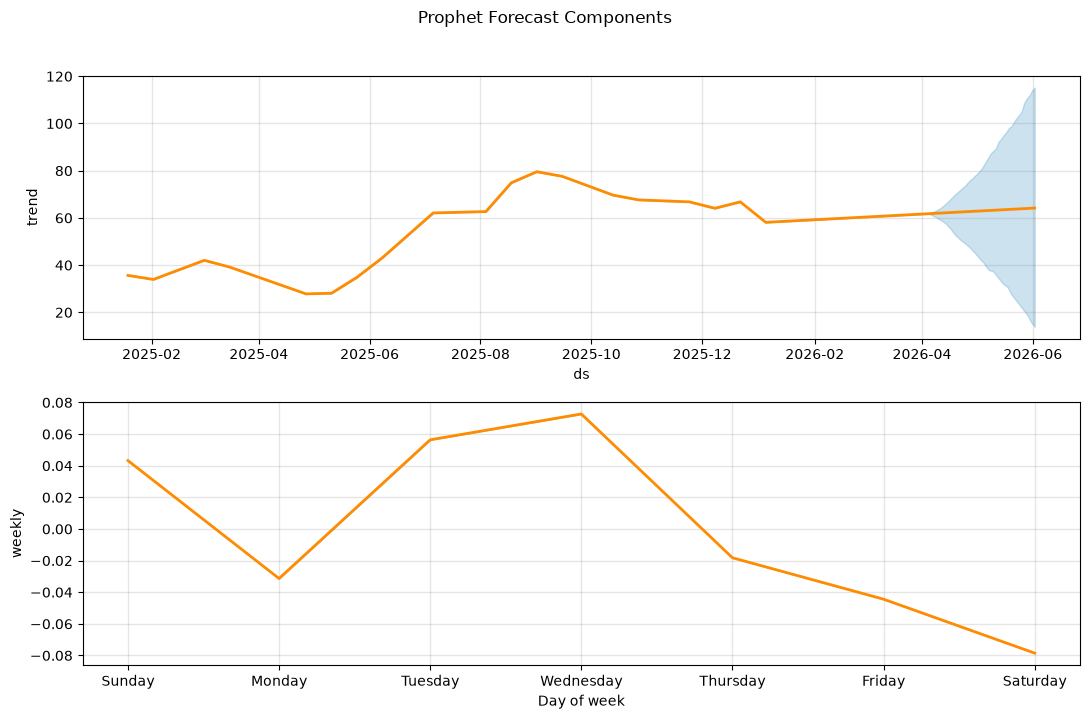

In [45]:
fig_components = prophet_model.plot_components(prophet_forecast)
for ax in fig_components.axes:
    for line in ax.lines:
        line.set_color("darkorange")
        line.set_linewidth(2)
fig_components.set_size_inches(11, 7)
fig_components.suptitle("Prophet Forecast Components", y=1.02)
plt.tight_layout()
plt.savefig("figures/figure_17_prophet_components.png", dpi=300, bbox_inches="tight")
plt.show()


## 16. Model Evaluation

The forecasting performance of the ARMA and Prophet models was evaluated using MAE, RMSE, and MAPE. These metrics were calculated on the test dataset to compare how accurately each model predicted unseen gas price observations.

In [46]:
def calculate_metrics(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return mae, rmse, mape

arma_mae, arma_rmse, arma_mape = calculate_metrics(test["price"], test["arma_forecast"])
prophet_mae, prophet_rmse, prophet_mape = calculate_metrics(test["price"], test["prophet_forecast"])

evaluation_table = pd.DataFrame({
    "Model": ["ARMA on First Differenced Series", "Prophet"],
    "MAE": [arma_mae, prophet_mae],
    "RMSE": [arma_rmse, prophet_rmse],
    "MAPE (%)": [arma_mape, prophet_mape]
})

display(evaluation_table)
evaluation_table.to_csv("tables/table_07_model_evaluation_metrics.csv", index=False)


,Model,MAE,RMSE,MAPE (%)
0,ARMA on First Differenced Series,7.180442,8.362644,8.880741
1,Prophet,14.882736,15.698373,18.746497


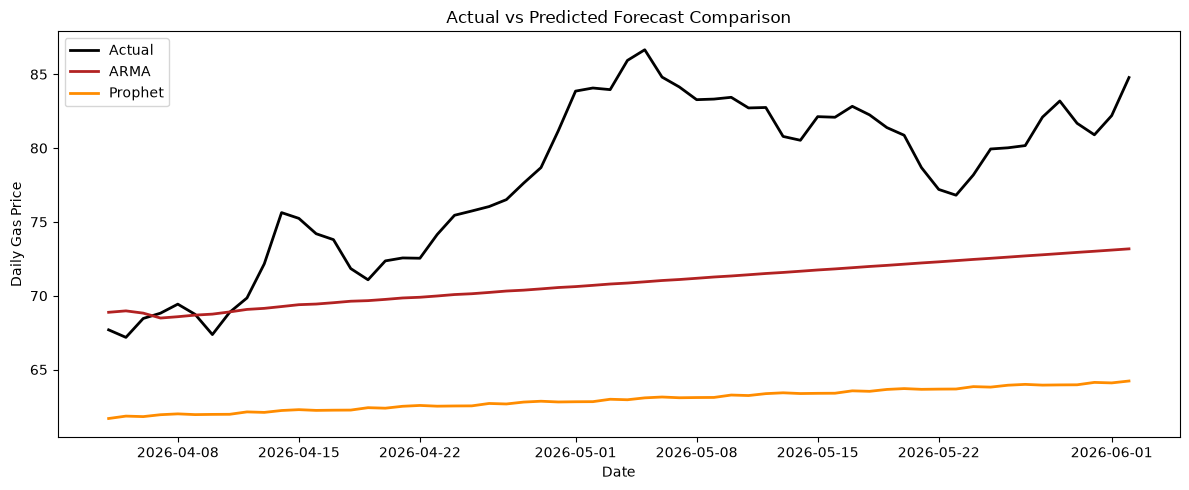

In [47]:
plt.figure(figsize=(12, 5))
plt.plot(test["date"], test["price"], color="black", linewidth=2, label="Actual")
plt.plot(test["date"], test["arma_forecast"], color="firebrick", linewidth=2, label="ARMA")
plt.plot(test["date"], test["prophet_forecast"], color="darkorange", linewidth=2, label="Prophet")
plt.title("Actual vs Predicted Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Daily Gas Price")
plt.legend()
plt.tight_layout()
plt.savefig("figures/figure_18_actual_vs_predicted_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

test_predictions = test[[
    "date", "price",  
    "arma_diff_forecast", "arma_forecast", "arma_lower_ci", "arma_upper_ci",
    "prophet_forecast", "prophet_lower_ci", "prophet_upper_ci"
]]

test_predictions.to_csv("tables/table_08_test_period_predictions.csv", index=False)


## 17. Future Forecast

Once the models have been evaluated, they are refitted using the full dataset to maximise the information available for forecasting. The ARMA forecasts are reconstructed back to the original gas price scale, and both ARMA and Prophet are used to generate forecasts for the following 730 days, equivalent to approximately 24 months.


In [48]:
future_steps = 730

# Final ARMA model using full differenced data
full_diff = df["price"].diff().dropna()

final_arma_order = (best_order[0], 0, best_order[2])

final_arma_model = SARIMAX(
    full_diff,
    order=final_arma_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

future_dates = pd.date_range(start=df["date"].max() + pd.Timedelta(days=1), periods=future_steps, freq="D")

final_arma_diff_forecast = final_arma_model.get_forecast(steps=future_steps)
final_arma_diff_mean = final_arma_diff_forecast.predicted_mean
final_arma_diff_ci = final_arma_diff_forecast.conf_int()

last_observed_price = df["price"].iloc[-1]

future_arma_mean = last_observed_price + np.cumsum(final_arma_diff_mean.values)
future_arma_lower = last_observed_price + np.cumsum(final_arma_diff_ci.iloc[:, 0].values)
future_arma_upper = last_observed_price + np.cumsum(final_arma_diff_ci.iloc[:, 1].values)

# Final Prophet model using full data
prophet_full = df[["date", "price"]].rename(columns={"date": "ds", "price": "y"})

final_prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False,
    changepoint_prior_scale=best_cps,
    interval_width=0.95
)

final_prophet_model.fit(prophet_full)

prophet_future_dates = final_prophet_model.make_future_dataframe(periods=future_steps, freq="D")
final_prophet_forecast = final_prophet_model.predict(prophet_future_dates).tail(future_steps)

future_forecast_table = pd.DataFrame({
    "date": future_dates,
    "arma_forecast": future_arma_mean,
    "arma_lower_ci": future_arma_lower,
    "arma_upper_ci": future_arma_upper,
    "prophet_forecast": final_prophet_forecast["yhat"].values,
    "prophet_lower_ci": final_prophet_forecast["yhat_lower"].values,
    "prophet_upper_ci": final_prophet_forecast["yhat_upper"].values
})

display(future_forecast_table.head())
future_forecast_table.to_csv("tables/table_09_future_24_month_forecast.csv", index=False)


17:21:46 - cmdstanpy - INFO - Chain [1] start processing
17:21:46 - cmdstanpy - INFO - Chain [1] done processing


,date,arma_forecast,arma_lower_ci,arma_upper_ci,prophet_forecast,prophet_lower_ci,prophet_upper_ci
0,2026-06-03,85.815640,83.910043,87.721237,86.593973,81.701491,91.719889
1,2026-06-04,85.437749,81.087894,89.787604,86.777121,81.601349,91.958894
2,2026-06-05,85.874987,79.060033,92.689940,87.029560,81.900927,92.365779
3,2026-06-06,86.051123,76.771044,95.331203,87.296358,82.337042,92.847711
4,2026-06-07,86.060884,74.307847,97.813922,87.706636,82.339471,92.854024


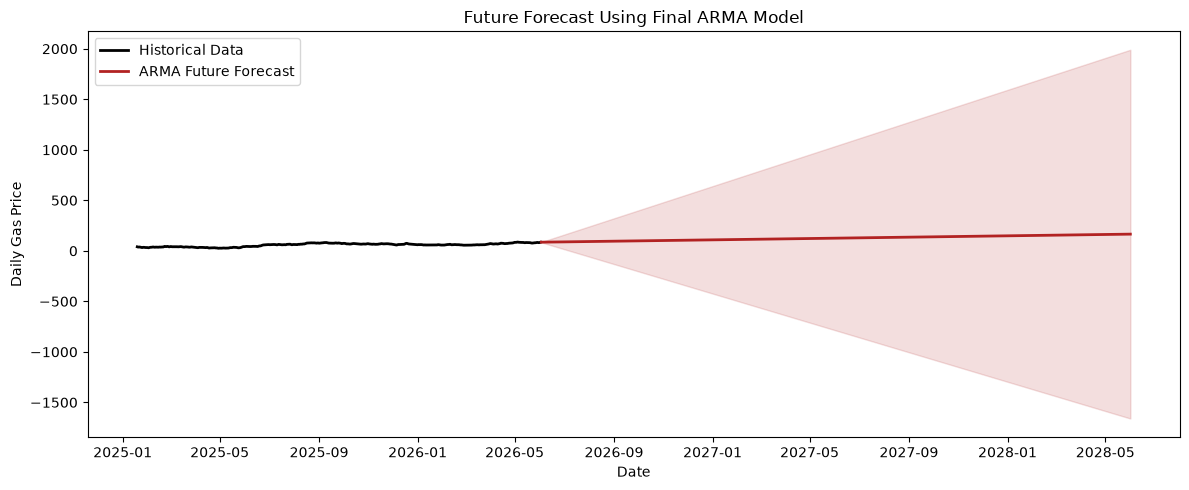

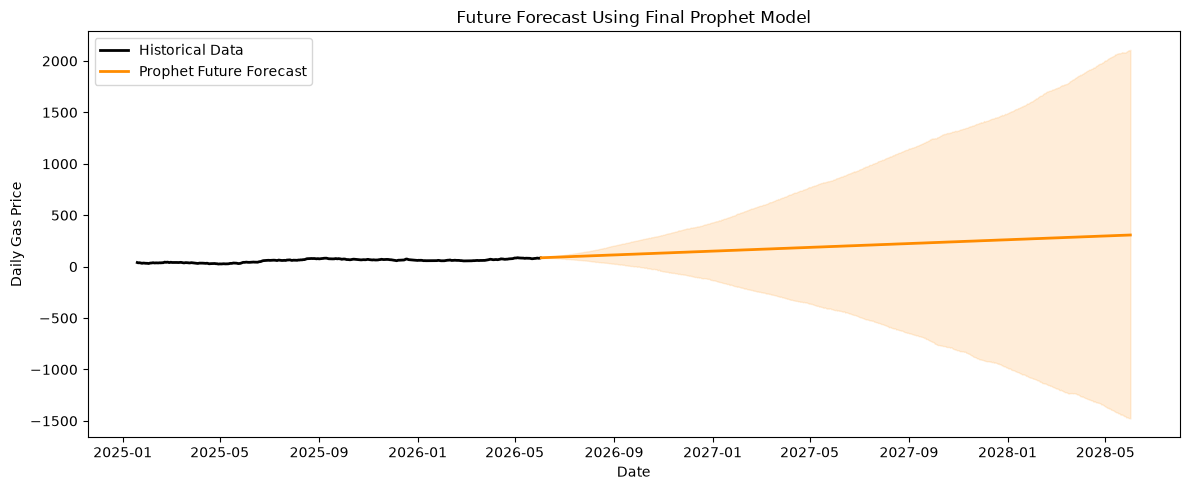

In [49]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["price"], color="black", linewidth=2, label="Historical Data")
plt.plot(future_forecast_table["date"], future_forecast_table["arma_forecast"], color="firebrick", linewidth=2, label="ARMA Future Forecast")
plt.fill_between(
    future_forecast_table["date"],
    future_forecast_table["arma_lower_ci"],
    future_forecast_table["arma_upper_ci"],
    color="firebrick",
    alpha=0.15
)
plt.title("Future Forecast Using Final ARMA Model")
plt.xlabel("Date")
plt.ylabel("Daily Gas Price")
plt.legend()
plt.tight_layout()
plt.savefig("figures/figure_19_future_arma_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["price"], color="black", linewidth=2, label="Historical Data")
plt.plot(future_forecast_table["date"], future_forecast_table["prophet_forecast"], color="darkorange", linewidth=2, label="Prophet Future Forecast")
plt.fill_between(
    future_forecast_table["date"],
    future_forecast_table["prophet_lower_ci"],
    future_forecast_table["prophet_upper_ci"],
    color="darkorange",
    alpha=0.15
)
plt.title("Future Forecast Using Final Prophet Model")
plt.xlabel("Date")
plt.ylabel("Daily Gas Price")
plt.legend()
plt.tight_layout()
plt.savefig("figures/figure_20_future_prophet_forecast.png", dpi=300, bbox_inches="tight")
plt.show()


## 18. Export Dataset

The dataset is saved so that the analysis can be replicated if needed and to maintain a clear record of the processed data used in this study.


In [50]:
df.to_csv("tables/table_10_cleaned_gas_price_dataset.csv", index=False)

print("Notebook completed successfully.")
print("This final version fits a true ARMA model on the first differenced stationary series and forecasts 24 months ahead.")
print("Figures saved in the 'figures' folder.")
print("Tables saved in the 'tables' folder.")


Notebook completed successfully.
This final version fits a true ARMA model on the first differenced stationary series and forecasts 24 months ahead.
Figures saved in the 'figures' folder.
Tables saved in the 'tables' folder.
